In [1]:
!pip install ultralytics opencv-python matplotlib seaborn pandas scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\snaga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data="dataset/data.yaml",   # YOUR dataset path
    epochs=50,
    imgsz=640,
    project="runs/train",
    name="seg_model"
)

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.202  Python-3.12.10 torch-2.8.0+cpu CPU (13th Gen Intel Core i5-13500H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=seg_model5, nbs=64, nms=False, opset=None

RuntimeError: Dataset 'dataset/data.yaml' error  'dataset/data.yaml' does not exist

In [4]:
from ultralytics import YOLO
import cv2

model = YOLO("runs/train/seg_model/weights/best.pt")

input_video = "input.mp4"
output_video = "output_result.mp4"

cap = cv2.VideoCapture(input_video)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)

    annotated_frame = results[0].plot()

    out.write(annotated_frame)

cap.release()
out.release()

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\train\\seg_model\\weights\\best.pt'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

log_file = "runs/train/seg_model/results.csv"
df = pd.read_csv(log_file)

plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/seg_loss"], label="Seg Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.plot(df["epoch"], df["val/seg_loss"], label="Val Seg Loss")
plt.legend()
plt.title("Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")

plt.legend()
plt.title("Performance Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

In [ ]:
from ultralytics.utils.metrics import ConfusionMatrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load validation results (generated automatically after training)
cm = ConfusionMatrix(task="detect")

# Path from validation labels and predictions (real dataset required)
cm.process_batch(preds=model.val())

matrix = cm.matrix

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


0: 384x640 1 cake, 207.0ms
Speed: 7.0ms preprocess, 207.0ms inference, 6.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 cake, 161.4ms
Speed: 4.9ms preprocess, 161.4ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 umbrella, 196.5ms
Speed: 4.4ms preprocess, 196.5ms inference, 4.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 umbrella, 168.7ms
Speed: 3.9ms preprocess, 168.7ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 umbrella, 199.0ms
Speed: 5.1ms preprocess, 199.0ms inference, 6.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 umbrella, 221.7ms
Speed: 4.6ms preprocess, 221.7ms inference, 5.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 umbrella, 245.8ms
Speed: 5.9ms preprocess, 245.8ms inference, 4.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 umbrella, 168.1ms
Speed: 4.6ms preprocess, 168.1ms inference, 4.5ms postprocess per 

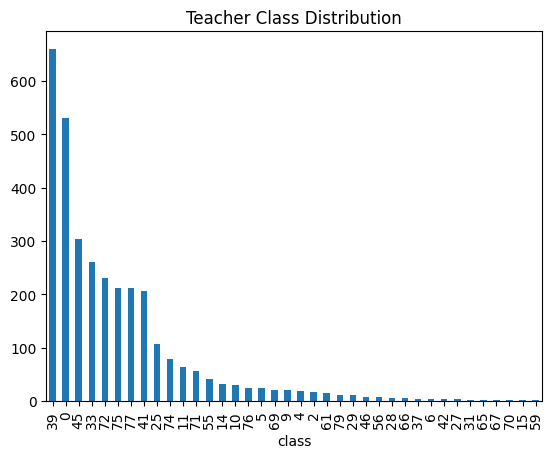

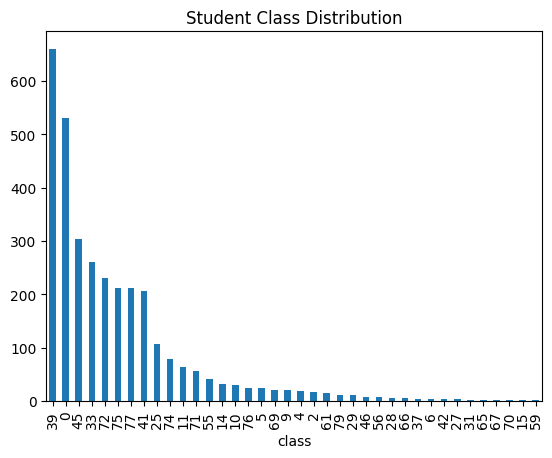

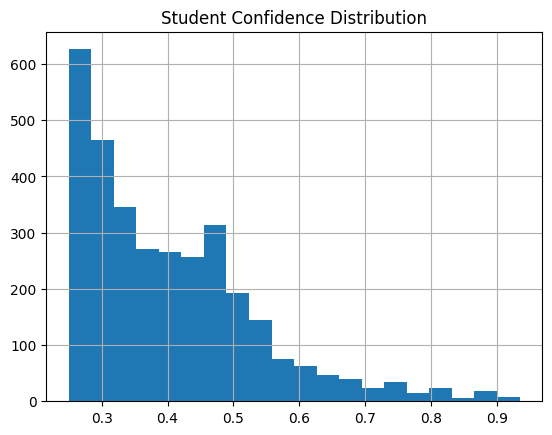

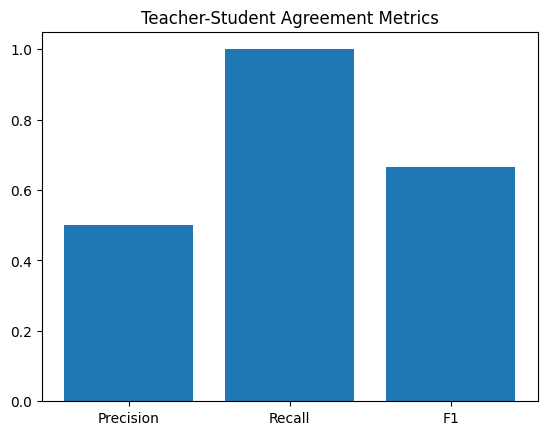


✔ output.mp4 generated
✔ teacher_pseudo_gt.csv created
✔ student_predictions.csv created


In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =========================
# CONFIG
# =========================
video_path = "input.mp4"

teacher_model = YOLO("yolov8n-seg.pt")  # pseudo GT generator
student_model = YOLO("yolov8n-seg.pt")  # can be different model

output_video = "output.mp4"

# =========================
# VIDEO SETUP
# =========================
cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# =========================
# STORAGE
# =========================
teacher_data = []
student_data = []

frame_id = 0

# =========================
# IOU FUNCTION
# =========================
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

# =========================
# PROCESS VIDEO
# =========================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    t_results = teacher_model(frame)[0]
    s_results = student_model(frame)[0]

    annotated = frame.copy()

    t_boxes = []
    s_boxes = []

    # ---------------------
    # TEACHER (pseudo GT)
    # ---------------------
    if t_results.boxes is not None:
        for i in range(len(t_results.boxes)):
            x1, y1, x2, y2 = map(int, t_results.boxes.xyxy[i])
            conf = float(t_results.boxes.conf[i])
            cls = int(t_results.boxes.cls[i])

            t_boxes.append([x1,y1,x2,y2,cls])

            teacher_data.append([frame_id, cls, conf, x1,y1,x2,y2])

            cv2.rectangle(annotated,(x1,y1),(x2,y2),(0,255,0),2)

    # ---------------------
    # STUDENT MODEL
    # ---------------------
    if s_results.boxes is not None:
        for i in range(len(s_results.boxes)):
            x1, y1, x2, y2 = map(int, s_results.boxes.xyxy[i])
            conf = float(s_results.boxes.conf[i])
            cls = int(s_results.boxes.cls[i])

            s_boxes.append([x1,y1,x2,y2,cls])

            student_data.append([frame_id, cls, conf, x1,y1,x2,y2])

            cv2.rectangle(annotated,(x1,y1),(x2,y2),(255,0,0),2)

    # ---------------------
    # SEGMENTATION MASKS (teacher)
    # ---------------------
    if t_results.masks is not None:
        masks = t_results.masks.data.cpu().numpy()
        for mask in masks:
            mask = cv2.resize(mask, (w, h))
            overlay = np.zeros_like(frame)
            overlay[:,:,1] = (mask*255).astype(np.uint8)
            annotated = cv2.addWeighted(annotated,1,overlay,0.3,0)

    out.write(annotated)
    frame_id += 1

cap.release()
out.release()

# =========================
# DATAFRAMES
# =========================
teacher_df = pd.DataFrame(teacher_data, columns=["frame","class","conf","x1","y1","x2","y2"])
student_df = pd.DataFrame(student_data, columns=["frame","class","conf","x1","y1","x2","y2"])

teacher_df.to_csv("teacher_pseudo_gt.csv", index=False)
student_df.to_csv("student_predictions.csv", index=False)

# =========================
# PSEUDO METRICS (AGREEMENT)
# =========================
TP = FP = FN = 0

for _, t in teacher_df.iterrows():
    t_box = [t.x1,t.y1,t.x2,t.y2]

    match_found = False

    same_frame = student_df[student_df["frame"] == t.frame]

    for _, s in same_frame.iterrows():
        s_box = [s.x1,s.y1,s.x2,s.y2]

        if iou(t_box, s_box) > 0.5:
            TP += 1
            match_found = True
            break

    if not match_found:
        FN += 1

FP = len(student_df)

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

# =========================
# PRINT RESULTS
# =========================
print("\n===== PSEUDO EVALUATION (TEACHER vs STUDENT) =====")
print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# =========================
# GRAPHS
# =========================

plt.figure()
teacher_df["class"].value_counts().plot(kind="bar")
plt.title("Teacher Class Distribution")
plt.show()

plt.figure()
student_df["class"].value_counts().plot(kind="bar")
plt.title("Student Class Distribution")
plt.show()

plt.figure()
student_df["conf"].hist(bins=20)
plt.title("Student Confidence Distribution")
plt.show()

plt.figure()
plt.bar(["Precision","Recall","F1"], [precision, recall, f1])
plt.title("Teacher-Student Agreement Metrics")
plt.show()

print("\n✔ output.mp4 generated")
print("✔ teacher_pseudo_gt.csv created")
print("✔ student_predictions.csv created")